In [1]:
# %pip install imbalanced-learn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import ADASYN
from collections import Counter
from sklearn.preprocessing import MinMaxScaler

In [3]:
data=pd.read_csv('../../data/processed/data_selected.csv')
data.head()

,Date,KOSPI 200_PPO_Hist,KOSPI 200_OG,GJR_VaR_5_t1,KOSPI 200_DMI14,Brent Crude Oil_return(%),VKOSPI_Close,NASDAQ_return(%),Risk_Label
0,2009-04-17,0.132689,1.339314,-2.736404,14.647201,0.0,35.49,0.157320,0
1,2009-04-20,0.056162,0.712077,-2.640948,12.666581,0.0,36.15,-3.953850,0
2,2009-04-21,-0.040207,-2.159026,-2.553087,9.561273,0.0,36.40,2.191930,0
3,2009-04-22,-0.038741,0.767616,-2.469280,13.493950,0.0,35.01,0.137996,0
4,2009-04-23,-0.003434,0.848630,-2.386329,15.409494,0.0,33.39,0.369276,0


### 데이터 분할

In [4]:
# train:valid:test 5:3:2
data_train = data[:int(len(data) * 0.5)]
data_valid = data[int(len(data) * 0.5):int(len(data) * 0.8)]
data_test = data[int(len(data) * 0.8):]

# X, y 분리
X_train = data_train.drop(['Risk_Label', 'Date'], axis=1)  # 설명변수, Date는 ML에서 불필요
y_train = data_train['Risk_Label']  # 반응변수
X_valid = data_valid.drop(['Risk_Label', 'Date'], axis=1)
y_valid = data_valid['Risk_Label']
X_test = data_test.drop(['Risk_Label', 'Date'], axis=1)
y_test = data_test['Risk_Label']

label_name_map = {0: 'LowRisk', 1: 'HighRisk'}
y_train_named = y_train.map(label_name_map)

print('train/valid/test:', len(data_train), len(data_valid), len(data_test))
print('y_train class:', y_train_named.value_counts().to_dict())

train/valid/test: 2054 1232 822
y_train class: {'LowRisk': 1859, 'HighRisk': 195}


### Min-Max Scaling

In [5]:
scaler = MinMaxScaler().set_output(transform="pandas")

# train에만 fit하고 valid/test에는 같은 scaler를 적용
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(data_valid.drop(['Risk_Label', 'Date'], axis=1))
X_test_scaled = scaler.transform(data_test.drop(['Risk_Label', 'Date'], axis=1))

X_valid_scaled["Risk_Label"] = data_valid['Risk_Label']
X_test_scaled["Risk_Label"] = data_test['Risk_Label']

print('train/valid/test:', len(data_train), len(data_valid), len(data_test))
print('y_train class:', y_train.value_counts().to_dict())

train/valid/test: 2054 1232 822
y_train class: {0: 1859, 1: 195}


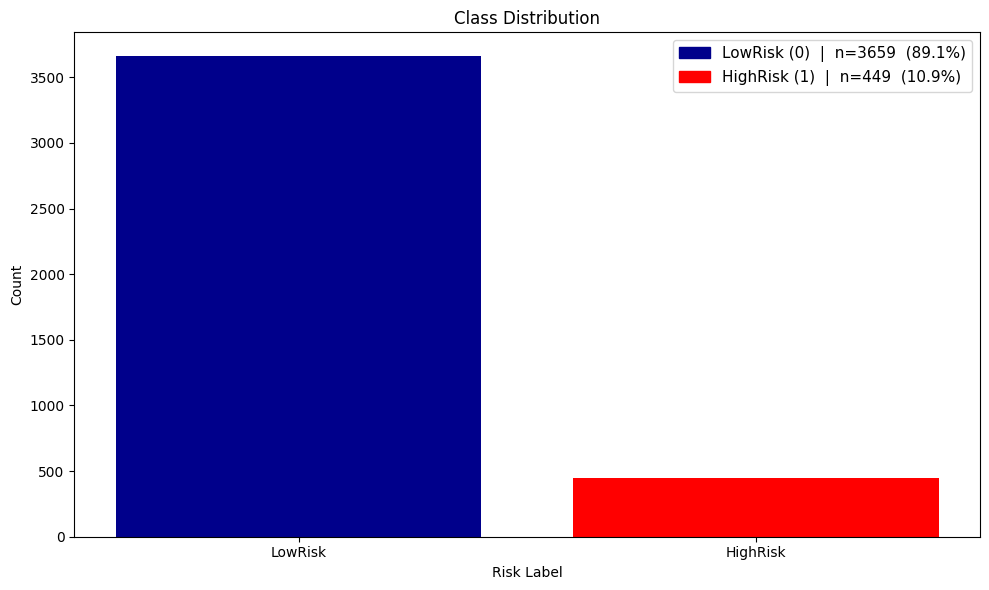

In [6]:
# 클래스 불균형 확인
counts = data['Risk_Label'].value_counts().sort_index()
label_name_map = {0: 'LowRisk', 1: 'HighRisk'}
colors = {0: 'darkblue', 1: 'red'}
total = counts.sum()

x_labels = [label_name_map.get(idx, str(idx)) for idx in counts.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    x_labels,
    counts.values,
    color=[colors.get(k, 'grey') for k in counts.index]
)

legend_labels = [
    f"{label_name_map.get(idx, idx)} ({idx})  |  n={cnt}  ({cnt/total*100:.1f}%)"
    for idx, cnt in zip(counts.index, counts.values)
]
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=colors.get(idx, 'grey'))
    for idx in counts.index
]
ax.legend(legend_patches, legend_labels, fontsize=11)

ax.set_xlabel('Risk Label')
ax.set_ylabel('Count')
ax.set_title('Class Distribution')
plt.tight_layout()
plt.show()

### **ADA**ptive **SYN**

In [7]:
# train 데이터에만 fit된 scaler 결과를 기준으로 ADASYN 적용
X = X_train_scaled.copy()

y_raw = y_train.copy()
if y_raw.dtype == object:
    y = y_raw.astype(str).str.strip().str.lower().map({'lowrisk': 0, 'highrisk': 1}).astype(int)
else:
    y = y_raw.astype(int)

adasyn = ADASYN(
    sampling_strategy='auto',
    random_state=1,
    n_neighbors=5
)

X_resampled, y_resampled = adasyn.fit_resample(X, y)

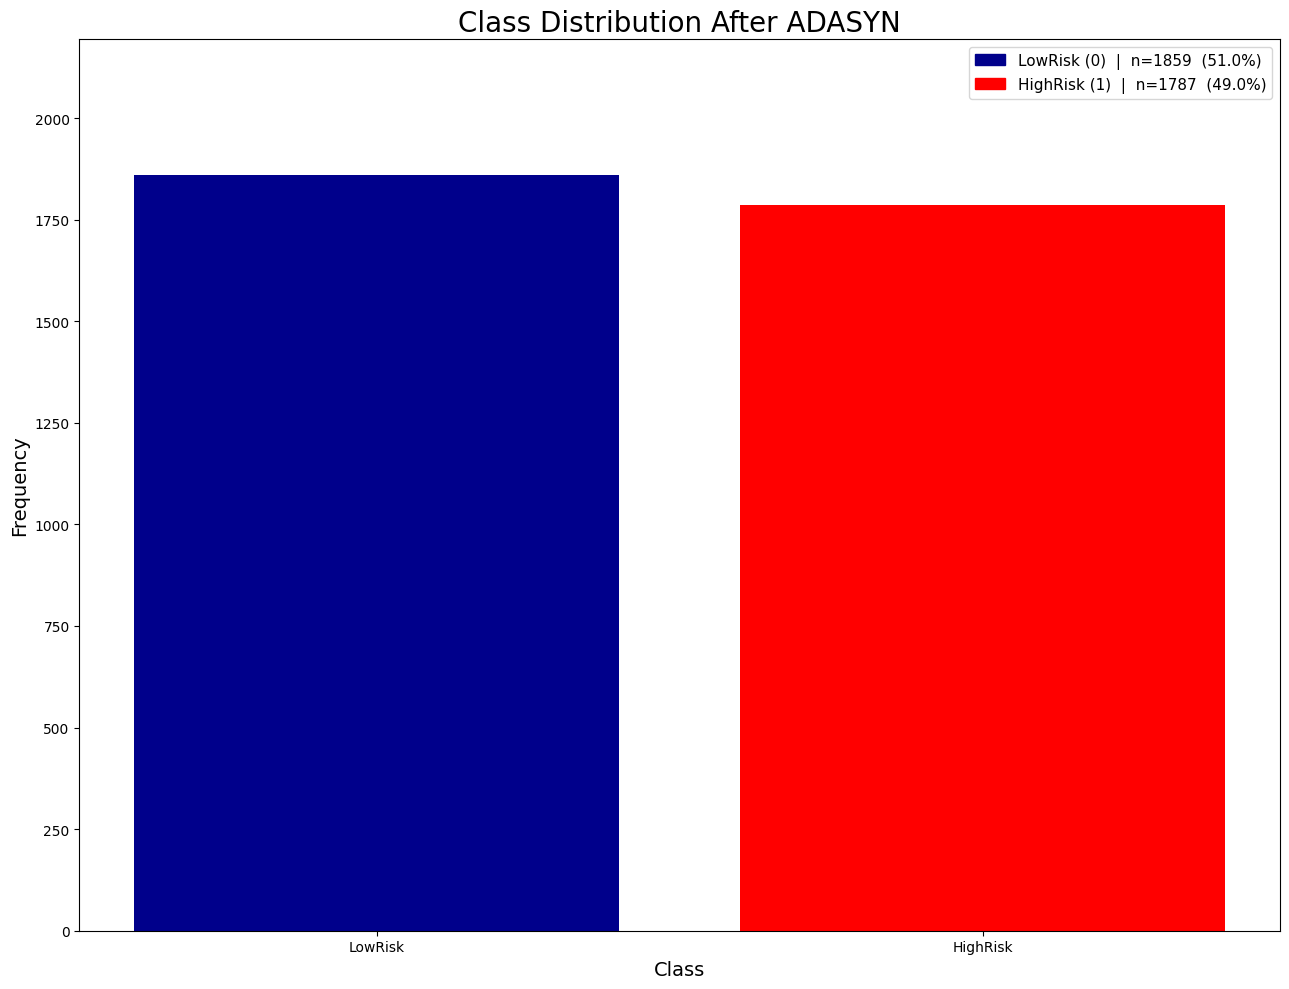

In [8]:
# 3. ADASYN 적용 후 클래스 분포 확인
counts = pd.Series(y_resampled).value_counts().sort_index()
label_name_map = {0: 'LowRisk', 1: 'HighRisk'}
colors = {0: 'darkblue', 1: 'red'}
total = counts.sum()

x_labels = [label_name_map.get(int(idx), str(idx)) for idx in counts.index]

fig, ax = plt.subplots(figsize=(13, 10))
ax.bar(
    x_labels,
    counts.values,
    color=[colors.get(int(k), 'grey') for k in counts.index]
)

# legend에 이름, index, count, 비율 표시
legend_labels = [
    f"{label_name_map.get(int(idx), idx)} ({int(idx)})  |  n={cnt}  ({cnt/total*100:.1f}%)"
    for idx, cnt in zip(counts.index, counts.values)
]
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=colors.get(int(idx), 'grey'))
    for idx in counts.index
]
ax.legend(legend_patches, legend_labels, fontsize=11)

ax.set_xlabel('Class', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
ax.set_title('Class Distribution After ADASYN', fontsize=20)
plt.ylim(0, max(counts.values) * 1.18)
plt.tight_layout()
plt.show()

In [9]:
# 4. train데이터 다시 데이터프레임으로 합치기
data_train_adasyn = X_resampled.copy()
data_train_adasyn['Risk_Label'] = data_train['Risk_Label'].iloc[0]  # 원래 train 데이터의 Risk_Label 컬럼에서 첫 번째 값으로 채우기
data_train_adasyn.head()

,KOSPI 200_PPO_Hist,KOSPI 200_OG,GJR_VaR_5_t1,KOSPI 200_DMI14,Brent Crude Oil_return(%),VKOSPI_Close,NASDAQ_return(%),Risk_Label
0,0.691619,0.728036,0.632405,0.681672,0.545323,0.638029,0.593612,0
1,0.667715,0.655851,0.650815,0.660920,0.545323,0.654370,0.259590,0
2,0.637613,0.325430,0.667761,0.628385,0.545323,0.660560,0.758918,0
3,0.638071,0.662242,0.683924,0.669589,0.545323,0.626145,0.592042,0
4,0.649099,0.671566,0.699923,0.689658,0.545323,0.586036,0.610832,0


In [10]:
# ======= [누더기 패치 + 검증] 저장 직전 =======

# ① train ADASYN: Risk_Label이 iloc[0] 하나로 잘못 채워졌으므로 y_resampled로 덮어쓰기
data_train_adasyn['Risk_Label'] = y_resampled.values

# ② valid / test: X_valid_scaled 에 Risk_Label 이미 붙어있지만
#    원본 slice 인덱스가 그대로라 reset 후 y_valid/y_test로 재조립 (인덱스 틀어짐 방지)
data_valid_scaled = X_valid_scaled.drop(columns=['Risk_Label'], errors='ignore').copy().reset_index(drop=True)
data_valid_scaled['Risk_Label'] = y_valid.reset_index(drop=True)

data_test_scaled = X_test_scaled.drop(columns=['Risk_Label'], errors='ignore').copy().reset_index(drop=True)
data_test_scaled['Risk_Label'] = y_test.reset_index(drop=True)

# ③ 검증
print("=== Risk_Label 분포 검증 ===")
print(f"[train ADASYN] {data_train_adasyn['Risk_Label'].value_counts().sort_index().to_dict()}")
print(f"[valid]        {data_valid_scaled['Risk_Label'].value_counts().sort_index().to_dict()}")
print(f"[test]         {data_test_scaled['Risk_Label'].value_counts().sort_index().to_dict()}")

# 0/1 이외의 값이 끼어있으면 바로 터뜨리기
for name, df in [("train_adasyn", data_train_adasyn), ("valid", data_valid_scaled), ("test", data_test_scaled)]:
    bad = set(df['Risk_Label'].unique()) - {0, 1}
    assert not bad, f"[{name}] 이상한 Risk_Label 값 발견: {bad}"
print("✓ 모든 Risk_Label 정상 (0/1만 존재)")


=== Risk_Label 분포 검증 ===
[train ADASYN] {0: 1859, 1: 1787}
[valid]        {0: 1070, 1: 162}
[test]         {0: 730, 1: 92}
✓ 모든 Risk_Label 정상 (0/1만 존재)


In [11]:
# 5. CSV로 저장
data_train_adasyn.to_csv('../../data/processed/ADASYN/data_train_adasyn.csv', index=False)
data_valid_scaled.to_csv('../../data/processed/ADASYN/data_valid.csv', index=False)
data_test_scaled.to_csv('../../data/processed/ADASYN/data_test.csv', index=False)